# 2_classification_modeling
Train a Softmax (Multinomial) Logistic Regression model, perform CV and hyperparameter tuning, evaluate with confusion matrix and classification report.

In [7]:
%%bash
pip install -q scikit-learn pandas matplotlib seaborn joblib


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Load dataset
dataset = load_dataset('hpe-ai/medical-cases-classification-tutorial')
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])
X_train = train_df['transcription'].fillna('')
y_train = train_df['medical_specialty']
X_val = val_df['transcription'].fillna('')
y_val = val_df['medical_specialty']
X_test = test_df['transcription'].fillna('')
y_test = test_df['medical_specialty']


Repo card metadata block was not found. Setting CardData to empty.


In [8]:
# Build pipeline: TF-IDF (loaded) + Multinomial Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = joblib.load('artifacts/tfidf_vectorizer.joblib') if os.path.exists('artifacts/tfidf_vectorizer.joblib') else TfidfVectorizer(lowercase=True, stop_words='english', max_df=0.9, min_df=2, ngram_range=(1,2), max_features=50000)
pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        class_weight="balanced",   # handle imbalance
        random_state=42
    ))
])
pipeline

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## 2.1 Cross-validation & Hyperparameter tuning
We perform a small GridSearch over C (inverse regularization strength) and penalty.

In [9]:
# Strategic smaller grid search
param_grid = [
    {
        'tfidf__ngram_range': [(1, 2)],
        'tfidf__max_features': [50000],
        'clf__C': [0.1, 1.0, 10.0],
        'clf__penalty': ['l2']
    }
]

# This will only test 3 + 2 = 5 combinations × 5 folds = 25 fits
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=2
)

grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_pipeline = grid.best_estimator_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.9s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   5.0s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   5.1s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   5.4s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   5.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.1s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.8s
[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  13.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  10.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.fra

[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.7s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.6s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.4s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   8.7s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   8.2s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 1.0, 'clf__penalty': 'l2', 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.91      0.89      0.90       107
      ENT - Otolaryngology       0.73      0.62      0.67        13
          Gastroenterology       0.88      0.79      0.84        29
     Hematology - Oncology       0.70      0.84      0.76        19
                Nephrology       0.92      0.75      0.83        16
                 Neurology       0.63      0.56      0.59        48
              Neurosurgery       0.48      0.92      0.63        13
   Obstetrics / Gynecology       0.92      0.96      0.94        24
             Ophthalmology       1.00      1.00      1.00        10
                Orthopedic       0.88      0.71      0.79        62
     Pediatrics - Neonatal       0.62      1.00      0.77        10
   Psychiatry / Psychology       0.82      0.90      0.86        10
                 Radiology       0.38      0.56      0.45         9

                  accuracy                    

Text(0.5, 1.0, 'Confusion matrix (validation)')

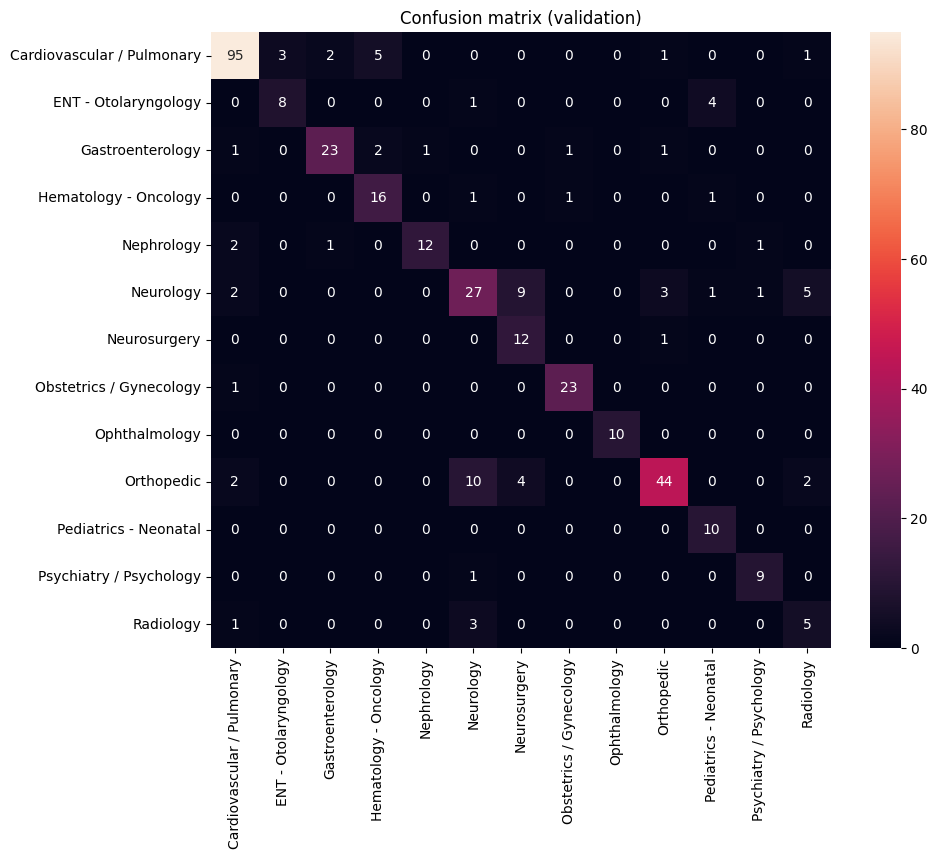

In [10]:
# Evaluate on validation set
y_val_pred = best_pipeline.predict(X_val)
print(classification_report(y_val, y_val_pred))
cm = confusion_matrix(y_val, y_val_pred, labels=best_pipeline.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
plt.title('Confusion matrix (validation)')

In [31]:
# Final evaluation on test set
y_test_pred = best_pipeline.predict(X_test)
print('Test classification report:')
print(classification_report(y_test, y_test_pred))

# Predict on test data
y_test_pred = best_pipeline.predict(X_test)

# Full report
print(classification_report(y_test, y_test_pred))

# Accuracy as percentage
acc = accuracy_score(y_test, y_test_pred) * 100
print(f"Test Accuracy: {acc:.2f}%")

Test classification report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.94      0.91      0.93       109
      ENT - Otolaryngology       0.71      0.71      0.71        14
          Gastroenterology       0.95      0.85      0.90        41
     Hematology - Oncology       0.52      0.73      0.61        15
                Nephrology       0.88      0.70      0.78        10
                 Neurology       0.67      0.68      0.67        47
              Neurosurgery       0.50      0.85      0.63        20
   Obstetrics / Gynecology       0.96      0.72      0.82        32
             Ophthalmology       0.80      0.73      0.76        11
                Orthopedic       0.88      0.61      0.72        57
     Pediatrics - Neonatal       0.33      1.00      0.50         3
   Psychiatry / Psychology       0.80      0.89      0.84         9
                 Radiology       0.00      0.00      0.00         2

                  

In [32]:
# Save final pipeline artifact
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_pipeline, 'artifacts/model_pipeline.joblib')
print('Saved artifacts/model_pipeline.joblib')

Saved artifacts/model_pipeline.joblib


In [33]:
import joblib

# Load trained model
pipeline = joblib.load("artifacts/model_pipeline.joblib")

# Example input
sample_text = "changes in movement such as tremors, weakness, or coordination problems, and sensory issues like numbness or tingling"

# Predict
prediction = pipeline.predict([sample_text])
print("Predicted Specialty:", prediction[0])


Predicted Specialty: Neurology


DETAILED F1 AND PRECISION SCORES

OVERALL METRICS:
Accuracy: 0.7838
F1 Macro: 0.7559
F1 Weighted: 0.7890
F1 Micro: 0.7838
Precision Macro: 0.7461
Precision Weighted: 0.8104
Recall Macro: 0.7957
Recall Weighted: 0.7838

PER-CLASS F1 AND PRECISION SCORES

Per-class metrics (sorted by F1-score):
                         Class  Precision  Recall  F1-Score
8                Ophthalmology     1.0000  0.9000    0.9474
7      Obstetrics / Gynecology     0.9200  0.9583    0.9388
0   Cardiovascular / Pulmonary     0.9208  0.8692    0.8942
11     Psychiatry / Psychology     0.8182  0.9000    0.8571
2             Gastroenterology     0.8800  0.7586    0.8148
4                   Nephrology     0.8571  0.7500    0.8000
9                   Orthopedic     0.8800  0.7097    0.7857
3        Hematology - Oncology     0.6667  0.8421    0.7442
10       Pediatrics - Neonatal     0.5556  1.0000    0.7143
1         ENT - Otolaryngology     0.7273  0.6154    0.6667
6                 Neurosurgery     0.4615  0.9

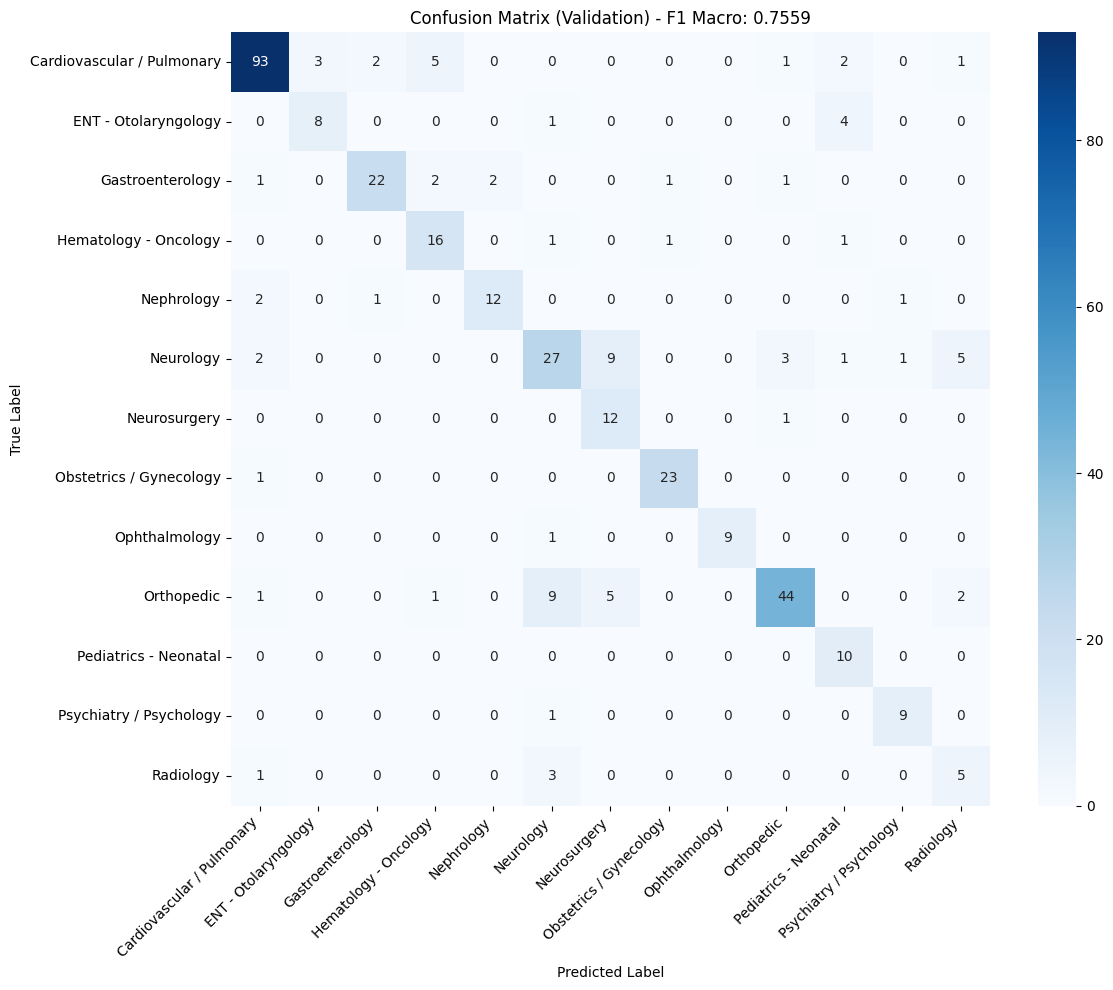

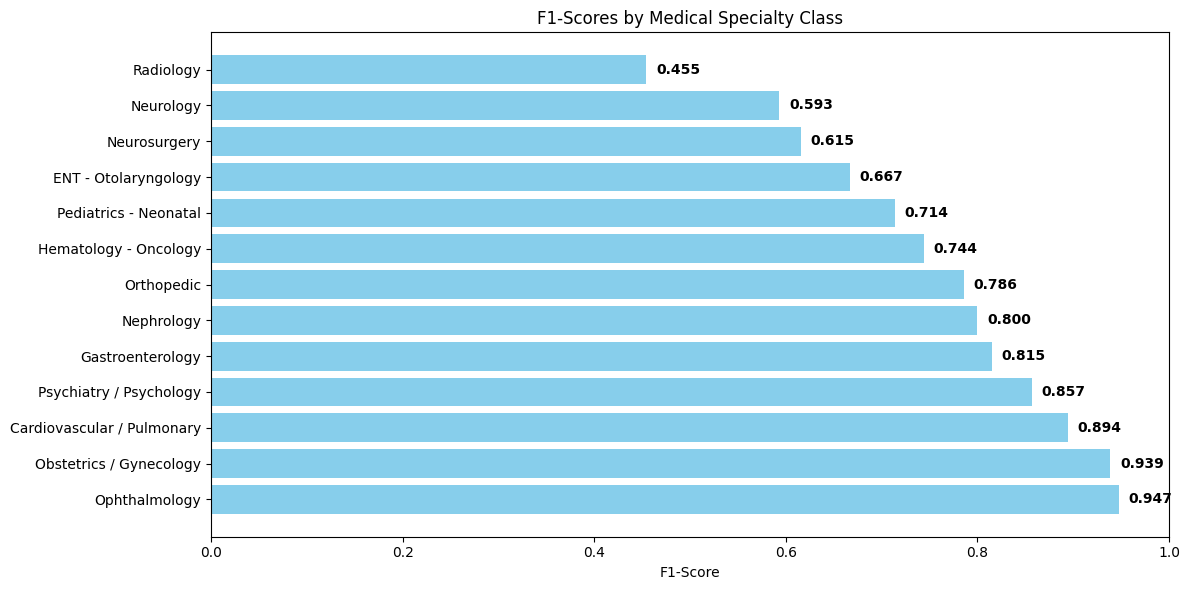

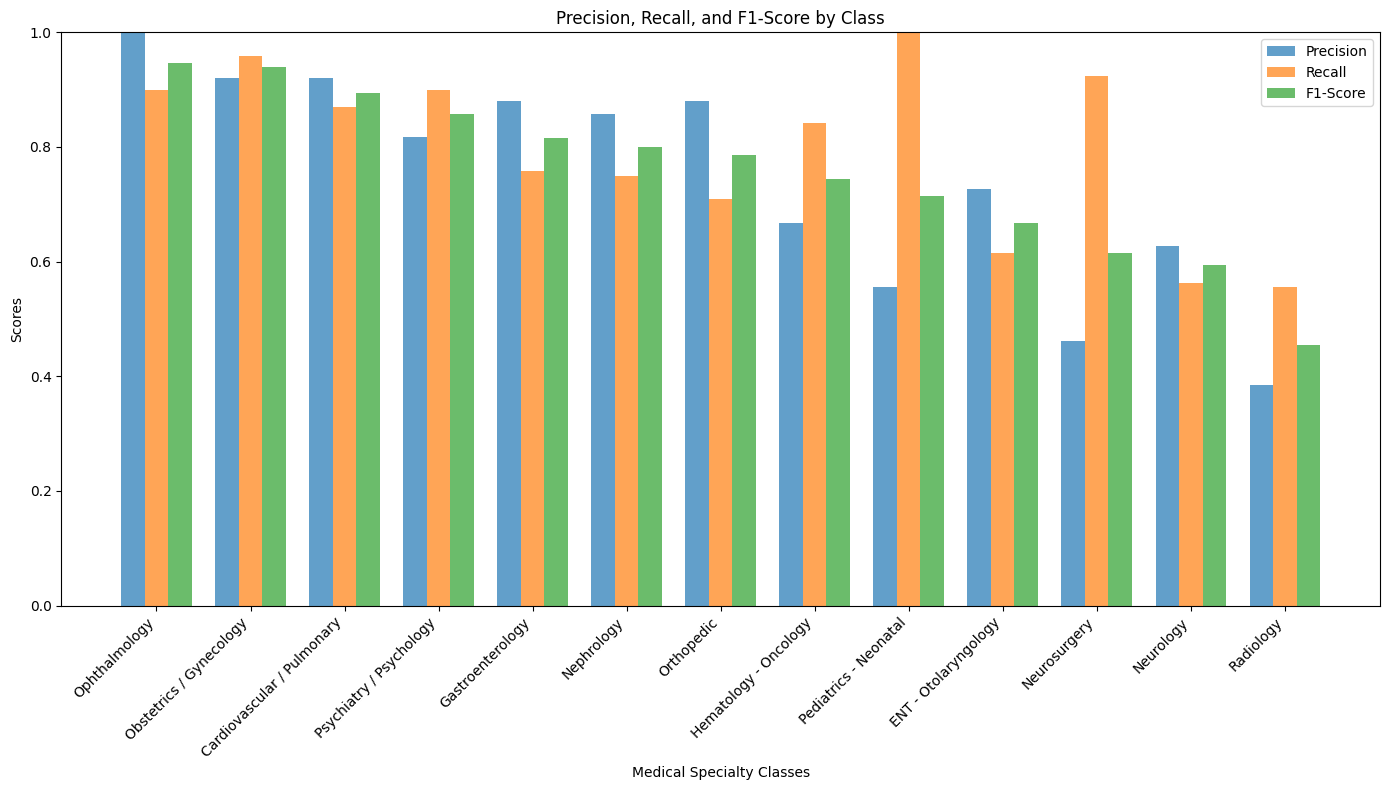


SUMMARY STATISTICS

F1-Score Statistics:
Best F1: 0.9474 (Ophthalmology)
Worst F1: 0.4545 (Radiology)
Average F1: 0.7559
Median F1: 0.7857
F1 Std Dev: 0.1451

Precision Statistics:
Average Precision: 0.7461
Average Recall: 0.7957

TEST SET EVALUATION
Test Set Accuracy: 0.7784
Test Set F1 Macro: 0.6828
Validation-Test F1 Difference: 0.0731

PERFORMANCE ANALYSIS

High performing classes (F1 > 0.8):
  Ophthalmology: F1 = 0.947
  Obstetrics / Gynecology: F1 = 0.939
  Cardiovascular / Pulmonary: F1 = 0.894
  Psychiatry / Psychology: F1 = 0.857
  Gastroenterology: F1 = 0.815

Low performing classes (F1 < 0.6):
  Neurology: F1 = 0.593, Precision = 0.628, Recall = 0.562
  Radiology: F1 = 0.455, Precision = 0.385, Recall = 0.556


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Evaluate on validation set
y_val_pred = best_pipeline.predict(X_val)

# 1. Detailed F1 and Precision Scores
print("="*70)
print("DETAILED F1 AND PRECISION SCORES")
print("="*70)

# Overall F1 scores
f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')
f1_micro = f1_score(y_val, y_val_pred, average='micro')

# Overall Precision scores
precision_macro = precision_score(y_val, y_val_pred, average='macro')
precision_weighted = precision_score(y_val, y_val_pred, average='weighted')
precision_micro = precision_score(y_val, y_val_pred, average='micro')

# Overall Recall scores
recall_macro = recall_score(y_val, y_val_pred, average='macro')
recall_weighted = recall_score(y_val, y_val_pred, average='weighted')

# Accuracy
accuracy = accuracy_score(y_val, y_val_pred)

print(f"\nOVERALL METRICS:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")
print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")

# 2. Per-class F1 and Precision scores
print(f"\n{'='*70}")
print("PER-CLASS F1 AND PRECISION SCORES")
print(f"{'='*70}")

# Get per-class scores
f1_per_class = f1_score(y_val, y_val_pred, average=None)
precision_per_class = precision_score(y_val, y_val_pred, average=None)
recall_per_class = recall_score(y_val, y_val_pred, average=None)

# Create a DataFrame for better visualization
metrics_df = pd.DataFrame({
    'Class': best_pipeline.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
})

# Sort by F1-score descending
metrics_df = metrics_df.sort_values('F1-Score', ascending=False)

print("\nPer-class metrics (sorted by F1-score):")
print(metrics_df.round(4))

# 3. Detailed classification report
print(f"\n{'='*70}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_val, y_val_pred))

# 4. Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred, labels=best_pipeline.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_pipeline.classes_, 
            yticklabels=best_pipeline.classes_)
plt.title('Confusion Matrix (Validation) - F1 Macro: {:.4f}'.format(f1_macro))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. F1-Score Visualization by Class
plt.figure(figsize=(12, 6))
bars = plt.barh(metrics_df['Class'], metrics_df['F1-Score'], color='skyblue')
plt.xlabel('F1-Score')
plt.title('F1-Scores by Medical Specialty Class')
plt.xlim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, metrics_df['F1-Score']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Precision-Recall-F1 Comparison by Class
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(metrics_df['Class']))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.7)
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', alpha=0.7)
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.7)

ax.set_xlabel('Medical Specialty Classes')
ax.set_ylabel('Scores')
ax.set_title('Precision, Recall, and F1-Score by Class')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Class'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 7. Summary Statistics
print(f"\n{'='*70}")
print("SUMMARY STATISTICS")
print(f"{'='*70}")

print(f"\nF1-Score Statistics:")
print(f"Best F1: {metrics_df['F1-Score'].max():.4f} ({metrics_df.iloc[0]['Class']})")
print(f"Worst F1: {metrics_df['F1-Score'].min():.4f} ({metrics_df.iloc[-1]['Class']})")
print(f"Average F1: {metrics_df['F1-Score'].mean():.4f}")
print(f"Median F1: {metrics_df['F1-Score'].median():.4f}")
print(f"F1 Std Dev: {metrics_df['F1-Score'].std():.4f}")

print(f"\nPrecision Statistics:")
print(f"Average Precision: {metrics_df['Precision'].mean():.4f}")
print(f"Average Recall: {metrics_df['Recall'].mean():.4f}")

# 8. Test set evaluation (if you want to compare)
print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")

y_test_pred = best_pipeline.predict(X_test)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"Test Set F1 Macro: {test_f1_macro:.4f}")
print(f"Validation-Test F1 Difference: {f1_macro - test_f1_macro:.4f}")

# 9. Show which classes are performing well/poorly
print(f"\n{'='*70}")
print("PERFORMANCE ANALYSIS")
print(f"{'='*70}")

# Classes with F1 > 0.8
high_performing = metrics_df[metrics_df['F1-Score'] > 0.8]
if not high_performing.empty:
    print(f"\nHigh performing classes (F1 > 0.8):")
    for _, row in high_performing.iterrows():
        print(f"  {row['Class']}: F1 = {row['F1-Score']:.3f}")

# Classes with F1 < 0.6
low_performing = metrics_df[metrics_df['F1-Score'] < 0.6]
if not low_performing.empty:
    print(f"\nLow performing classes (F1 < 0.6):")
    for _, row in low_performing.iterrows():
        print(f"  {row['Class']}: F1 = {row['F1-Score']:.3f}, Precision = {row['Precision']:.3f}, Recall = {row['Recall']:.3f}")